In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set random seeds for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
file_id = "1sQgs550vWZPifj0j_HJ-i0WrbXo_MDI8Vgmm0IwJCJI"
gid = "1996190875"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv&gid={gid}"
df = pd.read_csv(url)

In [3]:
# Display basic information about the dataset
num_rows, num_cols = df.shape
print(f"Number of records (rows): {num_rows:,}")
print(f"Number of attributes (columns): {num_cols}")
print(f"\nColumn names:")
print(df.columns.tolist())


Number of records (rows): 200,000
Number of attributes (columns): 13

Column names:
['Student ID', 'Age', 'Gender', 'Height', 'Weight', 'Blood Type', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol', 'Diabetes', 'Smoking']


In [4]:
# Display first few rows
print("First 10 rows of the dataset:")
print(df.head(10))


First 10 rows of the dataset:
   Student ID   Age  Gender      Height     Weight Blood Type        BMI  \
0         1.0  18.0  Female  161.777924  72.354947          O  27.645835   
1         2.0   NaN    Male  152.069157  47.630941          B        NaN   
2         3.0  32.0  Female  182.537664  55.741083          A  16.729017   
3         NaN  30.0    Male  182.112867  63.332207          B  19.096042   
4         5.0  23.0  Female         NaN  46.234173          O        NaN   
5         6.0  32.0     NaN  151.491294  68.647805          B  29.912403   
6         7.0  21.0     NaN  172.949704  48.102744         AB  16.081635   
7         8.0  28.0    Male  186.489402  52.389752         AB  15.063921   
8         9.0  21.0    Male  155.039678  42.958703          B        NaN   
9        10.0  32.0     NaN  170.836315  50.783250          B  17.400435   

   Temperature  Heart Rate  Blood Pressure  Cholesterol Diabetes Smoking  
0          NaN        95.0           109.0        203.0   

In [5]:
# Display basic information about the dataset
print("Dataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      180000 non-null  float64
 1   Age             180000 non-null  float64
 2   Gender          180000 non-null  object 
 3   Height          180000 non-null  float64
 4   Weight          180000 non-null  float64
 5   Blood Type      180000 non-null  object 
 6   BMI             180000 non-null  float64
 7   Temperature     180000 non-null  float64
 8   Heart Rate      180000 non-null  float64
 9   Blood Pressure  180000 non-null  float64
 10  Cholesterol     180000 non-null  float64
 11  Diabetes        180000 non-null  object 
 12  Smoking         180000 non-null  object 
dtypes: float64(9), object(4)
memory usage: 19.8+ MB
None


In [6]:
# Display statistical summary (mean, std, min, max, etc.)
print("Statistical Summary of the Dataset:")
print(df.describe())


Statistical Summary of the Dataset:
          Student ID            Age         Height         Weight  \
count  180000.000000  180000.000000  180000.000000  180000.000000   
mean    49974.042078      26.021561     174.947103      69.971585   
std     28879.641657       4.890528      14.447560      17.322574   
min         1.000000      18.000000     150.000041      40.000578   
25%     24971.750000      22.000000     162.476110      54.969838   
50%     49943.500000      26.000000     174.899914      69.979384   
75%     74986.000000      30.000000     187.464417      84.980097   
max    100000.000000      34.000000     199.998639      99.999907   

                 BMI    Temperature     Heart Rate  Blood Pressure  \
count  180000.000000  180000.000000  180000.000000   180000.000000   
mean       23.338869      98.600948      79.503767      114.558033   
std         7.033554       0.500530      11.540755       14.403353   
min        10.074837      96.397835      60.000000       90.00

In [7]:
# Get numeric columns for visualization
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")


Numeric columns: ['Student ID', 'Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']
Categorical columns: ['Gender', 'Blood Type', 'Diabetes', 'Smoking']


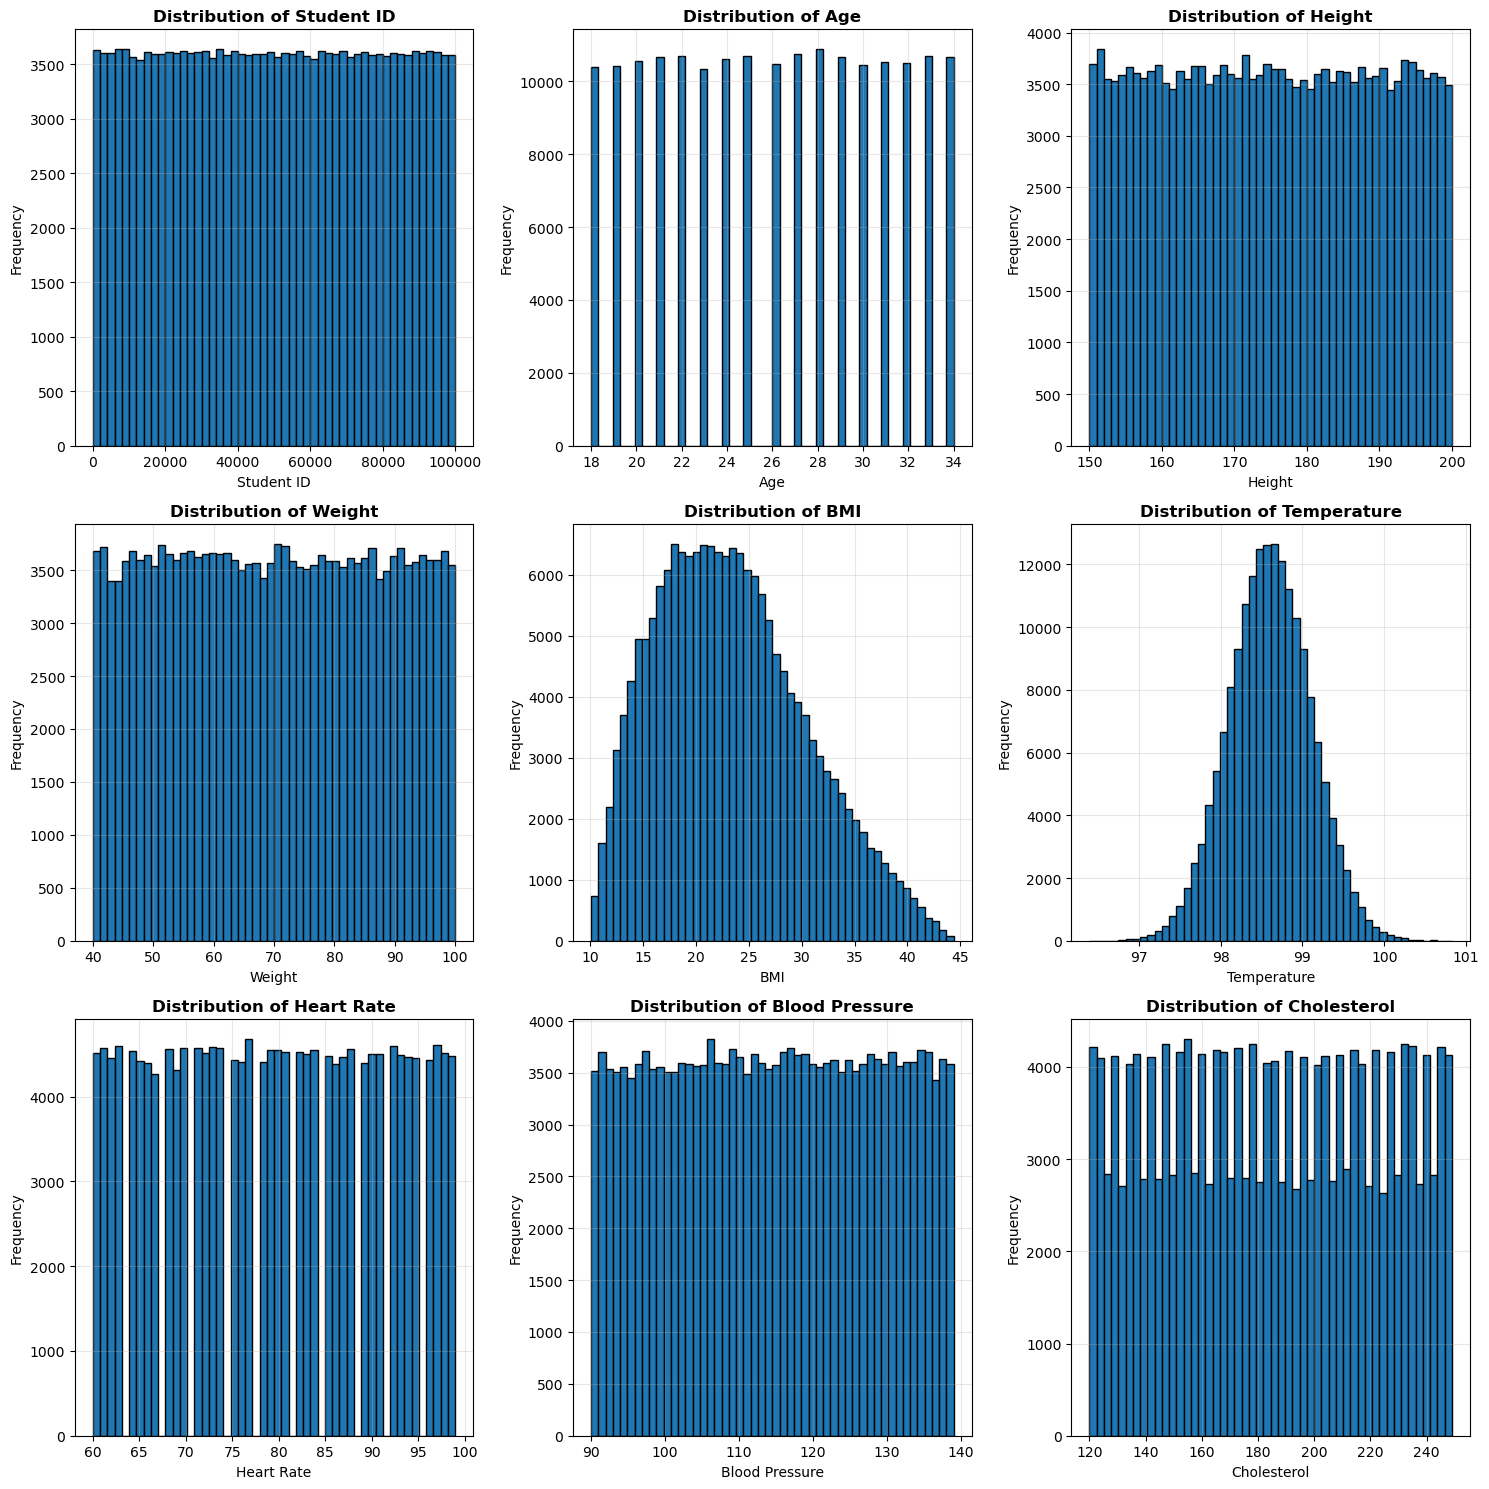

In [8]:
# Plot distribution of numeric columns
if numeric_cols:
    n_numeric = len(numeric_cols)
    n_cols = 3
    n_rows = (n_numeric + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_numeric > 1 else [axes]
    
    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            df[col].hist(bins=50, ax=axes[i], edgecolor='black')
            axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frequency')
            axes[i].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(n_numeric, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


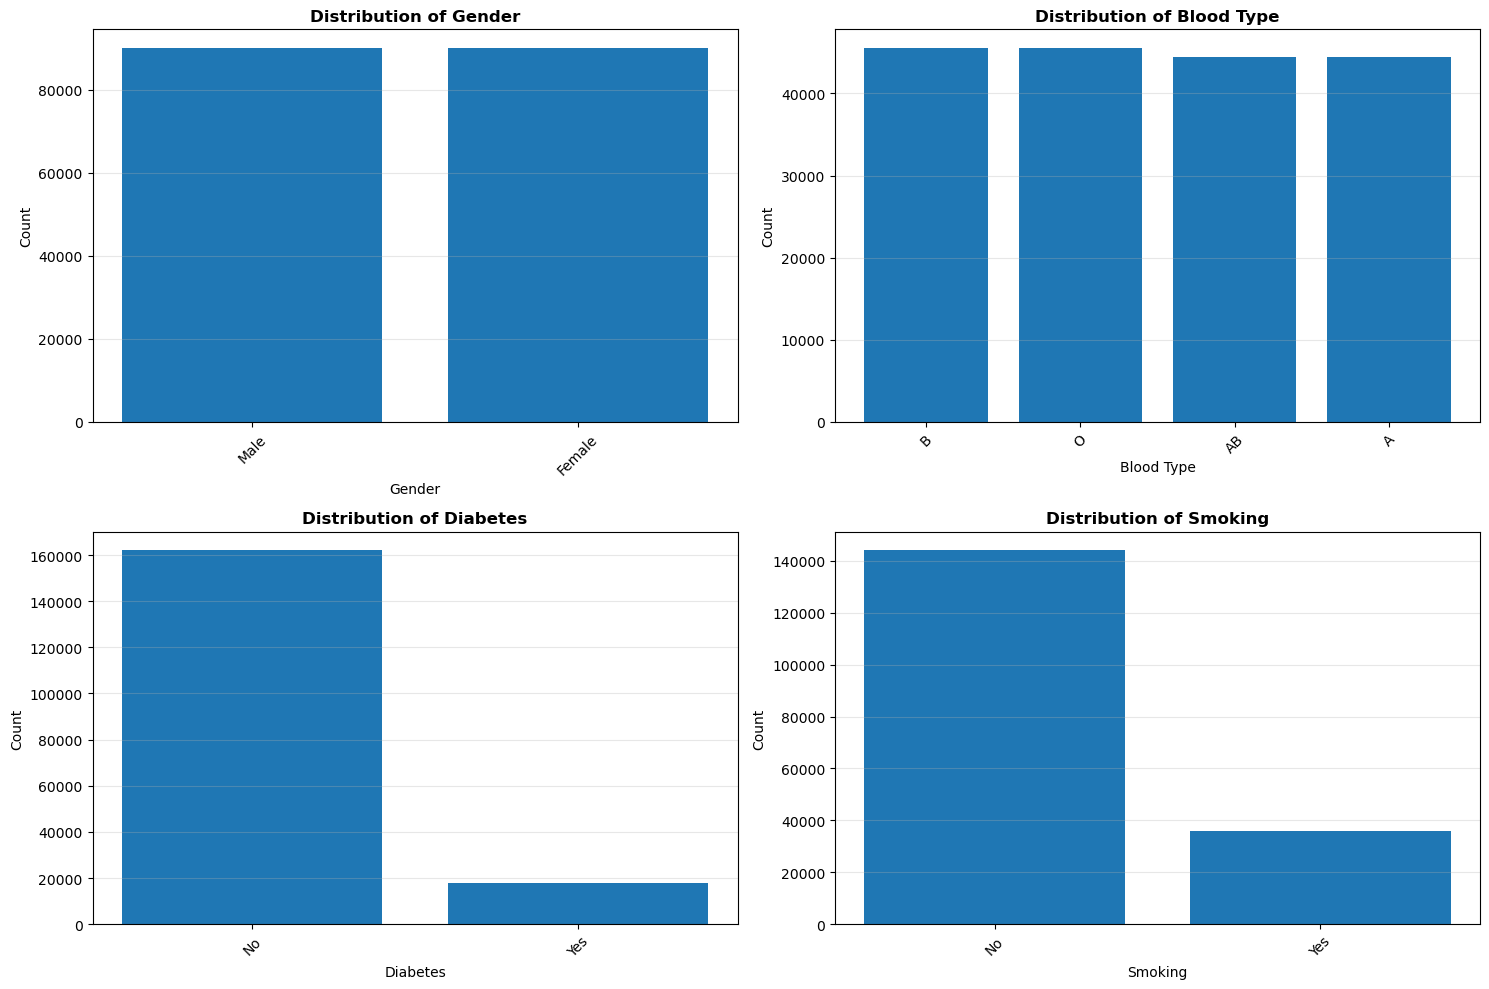

In [9]:
# Count plots for categorical columns
if categorical_cols:
    n_categorical = len(categorical_cols)
    n_cols = 2
    n_rows = (n_categorical + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_categorical > 1 else [axes]
    
    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            value_counts = df[col].value_counts()
            axes[i].bar(value_counts.index.astype(str), value_counts.values)
            axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Count')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, alpha=0.3, axis='y')
    
    # Hide empty subplots
    for i in range(n_categorical, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


In [10]:
# Count missing values per column
missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print("Missing Values per Column:")
print(missing_values)
print(f"\nTotal number of missing values in the dataset: {total_missing:,}")
print(f"Percentage of missing values: {(total_missing / (df.shape[0] * df.shape[1]) * 100):.2f}%")


Missing Values per Column:
Student ID        20000
Age               20000
Gender            20000
Height            20000
Weight            20000
Blood Type        20000
BMI               20000
Temperature       20000
Heart Rate        20000
Blood Pressure    20000
Cholesterol       20000
Diabetes          20000
Smoking           20000
dtype: int64

Total number of missing values in the dataset: 260,000
Percentage of missing values: 10.00%


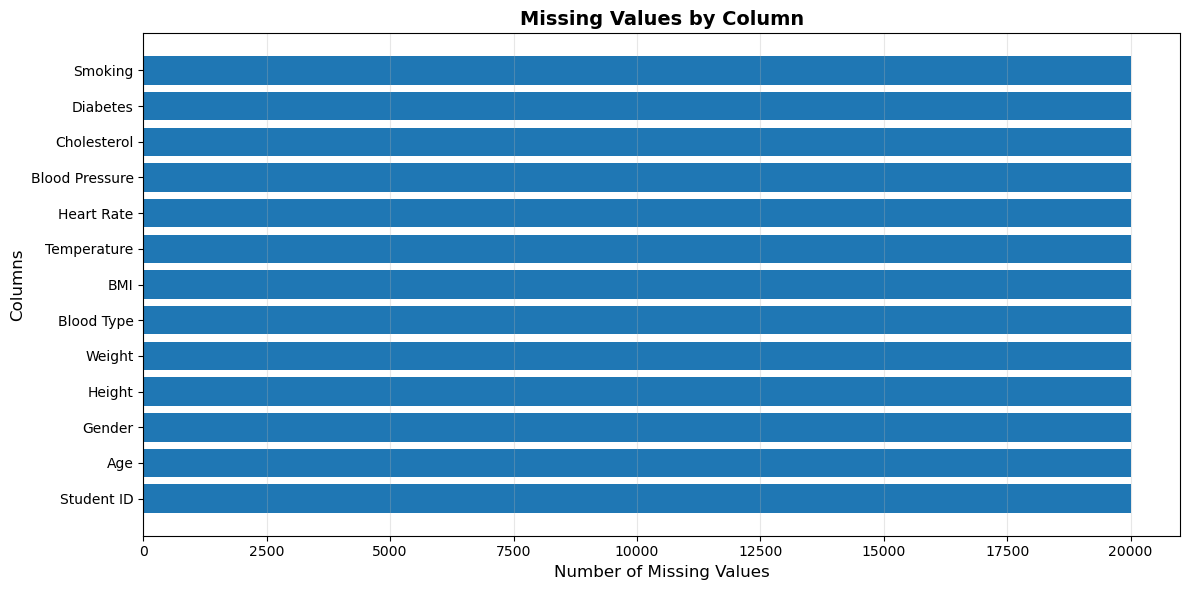


Columns with missing values:
            Column  Missing Count  Percentage
0       Student ID          20000        10.0
1              Age          20000        10.0
2           Gender          20000        10.0
3           Height          20000        10.0
4           Weight          20000        10.0
5       Blood Type          20000        10.0
6              BMI          20000        10.0
7      Temperature          20000        10.0
8       Heart Rate          20000        10.0
9   Blood Pressure          20000        10.0
10     Cholesterol          20000        10.0
11        Diabetes          20000        10.0
12         Smoking          20000        10.0


In [11]:
# Visualize missing values
if total_missing > 0:
    missing_df = pd.DataFrame({
        'Column': missing_values.index,
        'Missing Count': missing_values.values,
        'Percentage': (missing_values.values / len(df) * 100)
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    
    if len(missing_df) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.barh(missing_df['Column'], missing_df['Missing Count'])
        ax.set_xlabel('Number of Missing Values', fontsize=12)
        ax.set_ylabel('Columns', fontsize=12)
        ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
        
        print("\nColumns with missing values:")
        print(missing_df)
    else:
        print("No missing values found in the dataset!")
else:
    print("No missing values found in the dataset!")


In [12]:
# Count duplicate rows
num_duplicates = df.duplicated().sum()

print(f"Number of duplicate rows in the dataset: {num_duplicates:,}")
print(f"Percentage of duplicate rows: {(num_duplicates / len(df) * 100):.2f}%")

if num_duplicates > 0:
    print(f"\nFirst few duplicate rows:")
    duplicate_rows = df[df.duplicated(keep=False)]
    print(f"Total rows involved in duplicates: {len(duplicate_rows):,}")
    print(duplicate_rows.head(10))
else:
    print("\nNo duplicate rows found in the dataset!")


Number of duplicate rows in the dataset: 7,644
Percentage of duplicate rows: 3.82%

First few duplicate rows:
Total rows involved in duplicates: 15,288
    Student ID   Age  Gender      Height     Weight Blood Type        BMI  \
7          8.0  28.0    Male  186.489402  52.389752         AB  15.063921   
11        12.0  34.0  Female  182.416302  76.371050         AB  22.950992   
18        19.0  31.0  Female  158.790160  46.829849         AB  18.572723   
22        23.0  29.0  Female  179.909041  90.679436         AB  28.015787   
23        24.0  18.0    Male         NaN  52.521560         AB  13.570402   
24        25.0  27.0  Female  187.411623  81.219470         AB  23.124221   
35        36.0  21.0    Male  183.476287  61.469995          O  18.260106   
51        52.0  23.0    Male  174.338438  45.421333         AB  14.944231   
78        79.0  27.0  Female  187.852506  82.352369          B  23.336843   
86        87.0  34.0  Female  150.942632  90.580214          O  39.756624   



In [13]:
# Handle missing values and duplicates
print("Handling missing values and duplicates...")
print(f"Shape before: {df.shape}")

# Drop rows where Diabetes is missing
df = df.dropna(subset=['Diabetes'])

# Fill missing values in numerical columns with mean
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

# Fill missing values in categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col] = df[col].fillna(mode_value)

# Remove duplicates
df = df.drop_duplicates()

print(f"Shape after: {df.shape}")

Handling missing values and duplicates...
Shape before: (200000, 13)
Shape after: (169625, 13)


In [14]:
# Create input features (X) and output target (y)
target_column = 'Diabetes'
X = df.drop(target_column, axis=1)
y = df[target_column]

print(f"Features shape: {X.shape}, Labels shape: {y.shape}")

Features shape: (169625, 12), Labels shape: (169625,)


In [15]:
# Identify categorical columns in the feature matrix
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns: {categorical_features}")
print(f"Numerical columns: {numeric_features}")

# Check unique values in categorical columns
for col in categorical_features:
    unique_vals = X[col].unique()
    print(f"{col}: {unique_vals} (count: {len(unique_vals)})")

Categorical columns: ['Gender', 'Blood Type', 'Smoking']
Numerical columns: ['Student ID', 'Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']
Gender: ['Female' 'Male'] (count: 2)
Blood Type: ['O' 'B' 'A' 'AB'] (count: 4)
Smoking: ['No' 'Yes'] (count: 2)


In [16]:
# Apply encoding to categorical features
print(f"Shape before encoding: {X.shape}")

X_encoded = X.copy()

for col in categorical_features:
    unique_vals = X[col].unique()
    if len(unique_vals) == 2:
        # Label encoding for binary columns
        X_encoded[col] = X[col].map({unique_vals[0]: 0, unique_vals[1]: 1})
    else:
        # One-hot encoding for multi-class columns
        dummies = pd.get_dummies(X[col], prefix=col, drop_first=False)
        X_encoded = pd.concat([X_encoded.drop(col, axis=1), dummies], axis=1)

print(f"Shape after encoding: {X_encoded.shape}")

Shape before encoding: (169625, 12)
Shape after encoding: (169625, 15)


In [17]:
# Convert target variable to numeric
y_numeric = y.map({'Yes': 1, 'No': 0})

print(f"Target variable converted to numeric: {y_numeric.unique()}")

# Scaling of features
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def scale_features(X, original_numeric_cols, scaling_type='standard'):
    """
    Scale the features using Standard or Min-Max scaling.
    Only scales original numerical columns, not categorical (including one-hot and label encoded).
    """
    X_scaled = X.copy()
    
    if scaling_type == 'standard':
        scaler = StandardScaler()
    elif scaling_type == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("scaling_type must be 'standard' or 'minmax'")
    
    X_scaled[original_numeric_cols] = scaler.fit_transform(X[original_numeric_cols])
    
    return X_scaled

# Apply scaling (change 'standard' to 'minmax' if preferred)
X_scaled = scale_features(X_encoded, numeric_features, scaling_type='minmax')

print(f"Features scaled using Standard Scaling. Shape: {X_scaled.shape}")

Target variable converted to numeric: [0 1]
Features scaled using Standard Scaling. Shape: (169625, 15)


Correlation of each feature with target (Diabetes):
Age               0.003683
Cholesterol       0.003193
Gender            0.002658
Weight            0.002059
Blood Type_B      0.001973
Heart Rate        0.001873
BMI               0.001525
Blood Type_A      0.000478
Smoking          -0.000764
Blood Type_O     -0.000978
Blood Pressure   -0.001118
Blood Type_AB    -0.001361
Student ID       -0.001909
Temperature      -0.006135
Height           -0.006175
Name: Diabetes, dtype: float64


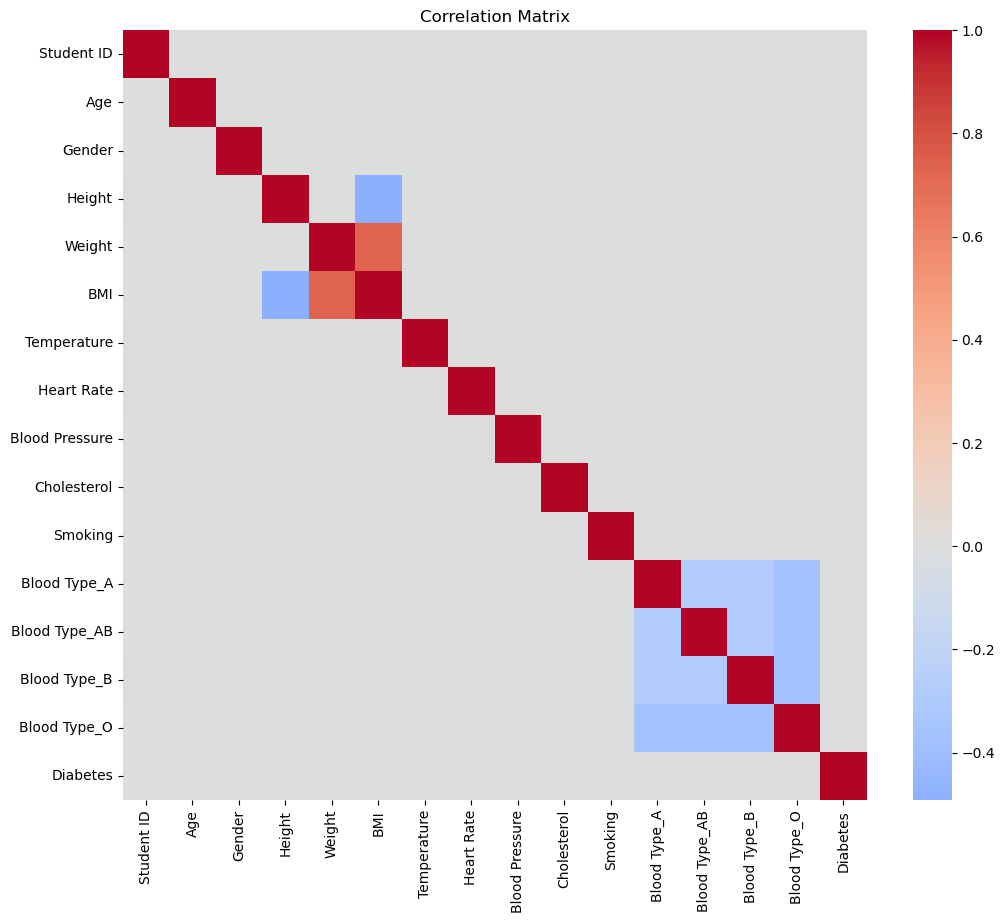


Top 10 features by absolute correlation: ['Height', 'Temperature', 'Age', 'Cholesterol', 'Gender', 'Weight', 'Blood Type_B', 'Student ID', 'Heart Rate', 'BMI']


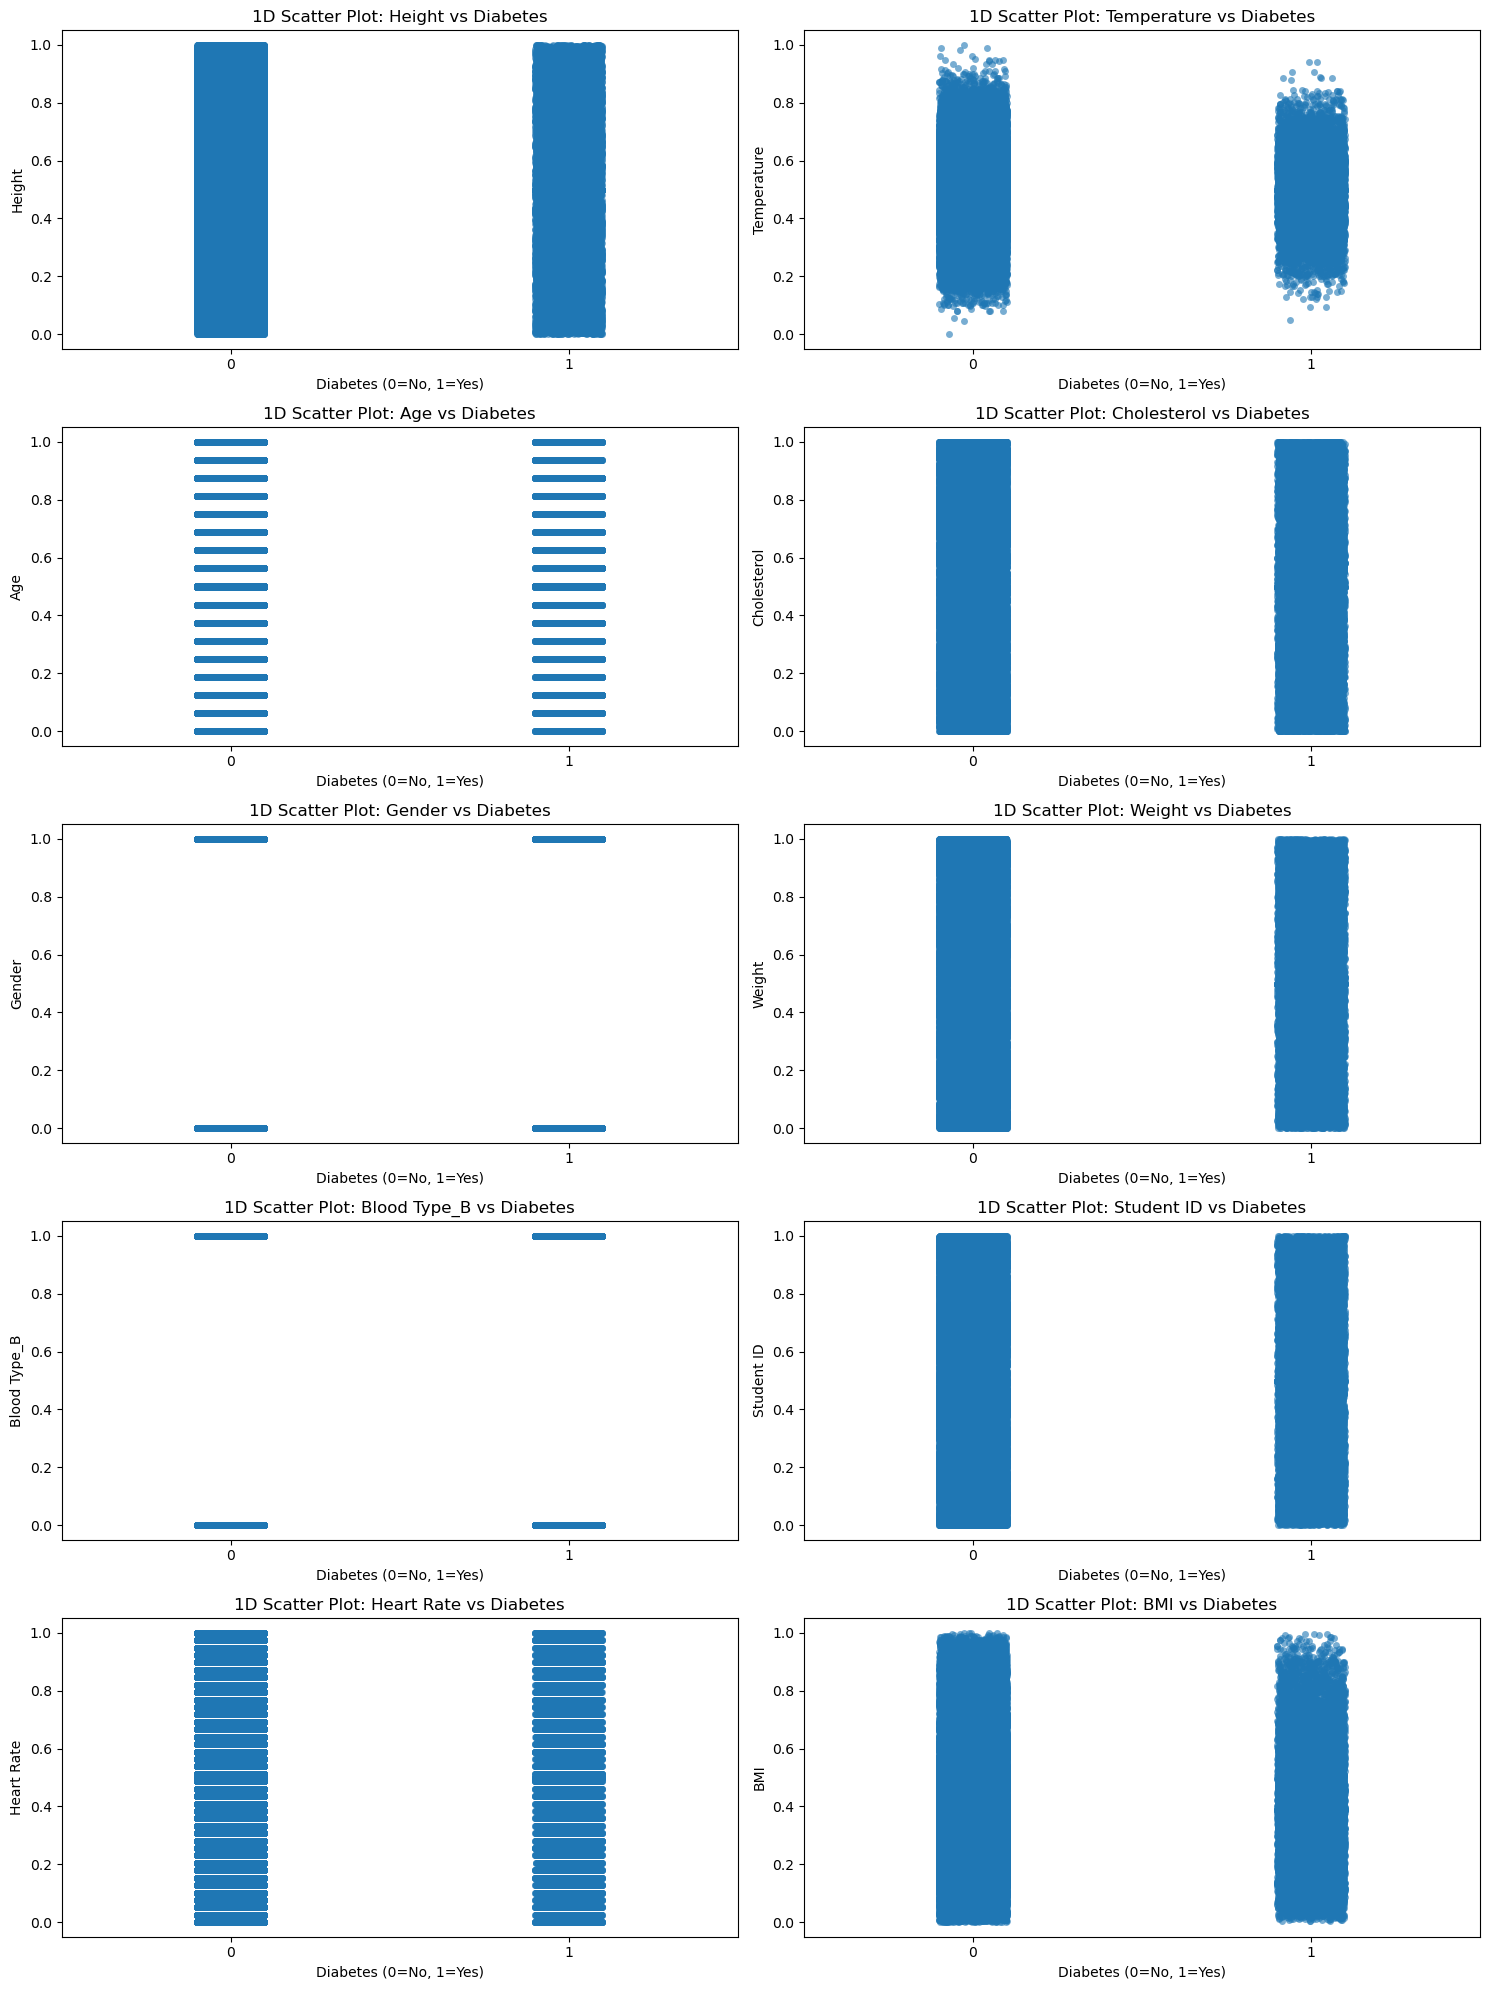

In [18]:
# Correlation analysis
# Combine features and target for correlation
data_for_corr = X_scaled.copy()
data_for_corr['Diabetes'] = y_numeric

# Compute correlations with target
correlations = data_for_corr.corr()['Diabetes'].drop('Diabetes')
print("Correlation of each feature with target (Diabetes):")
print(correlations.sort_values(ascending=False))

# Correlation matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(data_for_corr.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Top 10 features by absolute correlation
top_10_features = correlations.abs().sort_values(ascending=False).head(10).index
print(f"\nTop 10 features by absolute correlation: {list(top_10_features)}")

# 1D scatter plots for top 10 features
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, feature in enumerate(top_10_features):
    sns.stripplot(x='Diabetes', y=feature, data=data_for_corr, ax=axes[i], jitter=True, alpha=0.6)
    axes[i].set_title(f'1D Scatter Plot: {feature} vs Diabetes')
    axes[i].set_xlabel('Diabetes (0=No, 1=Yes)')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

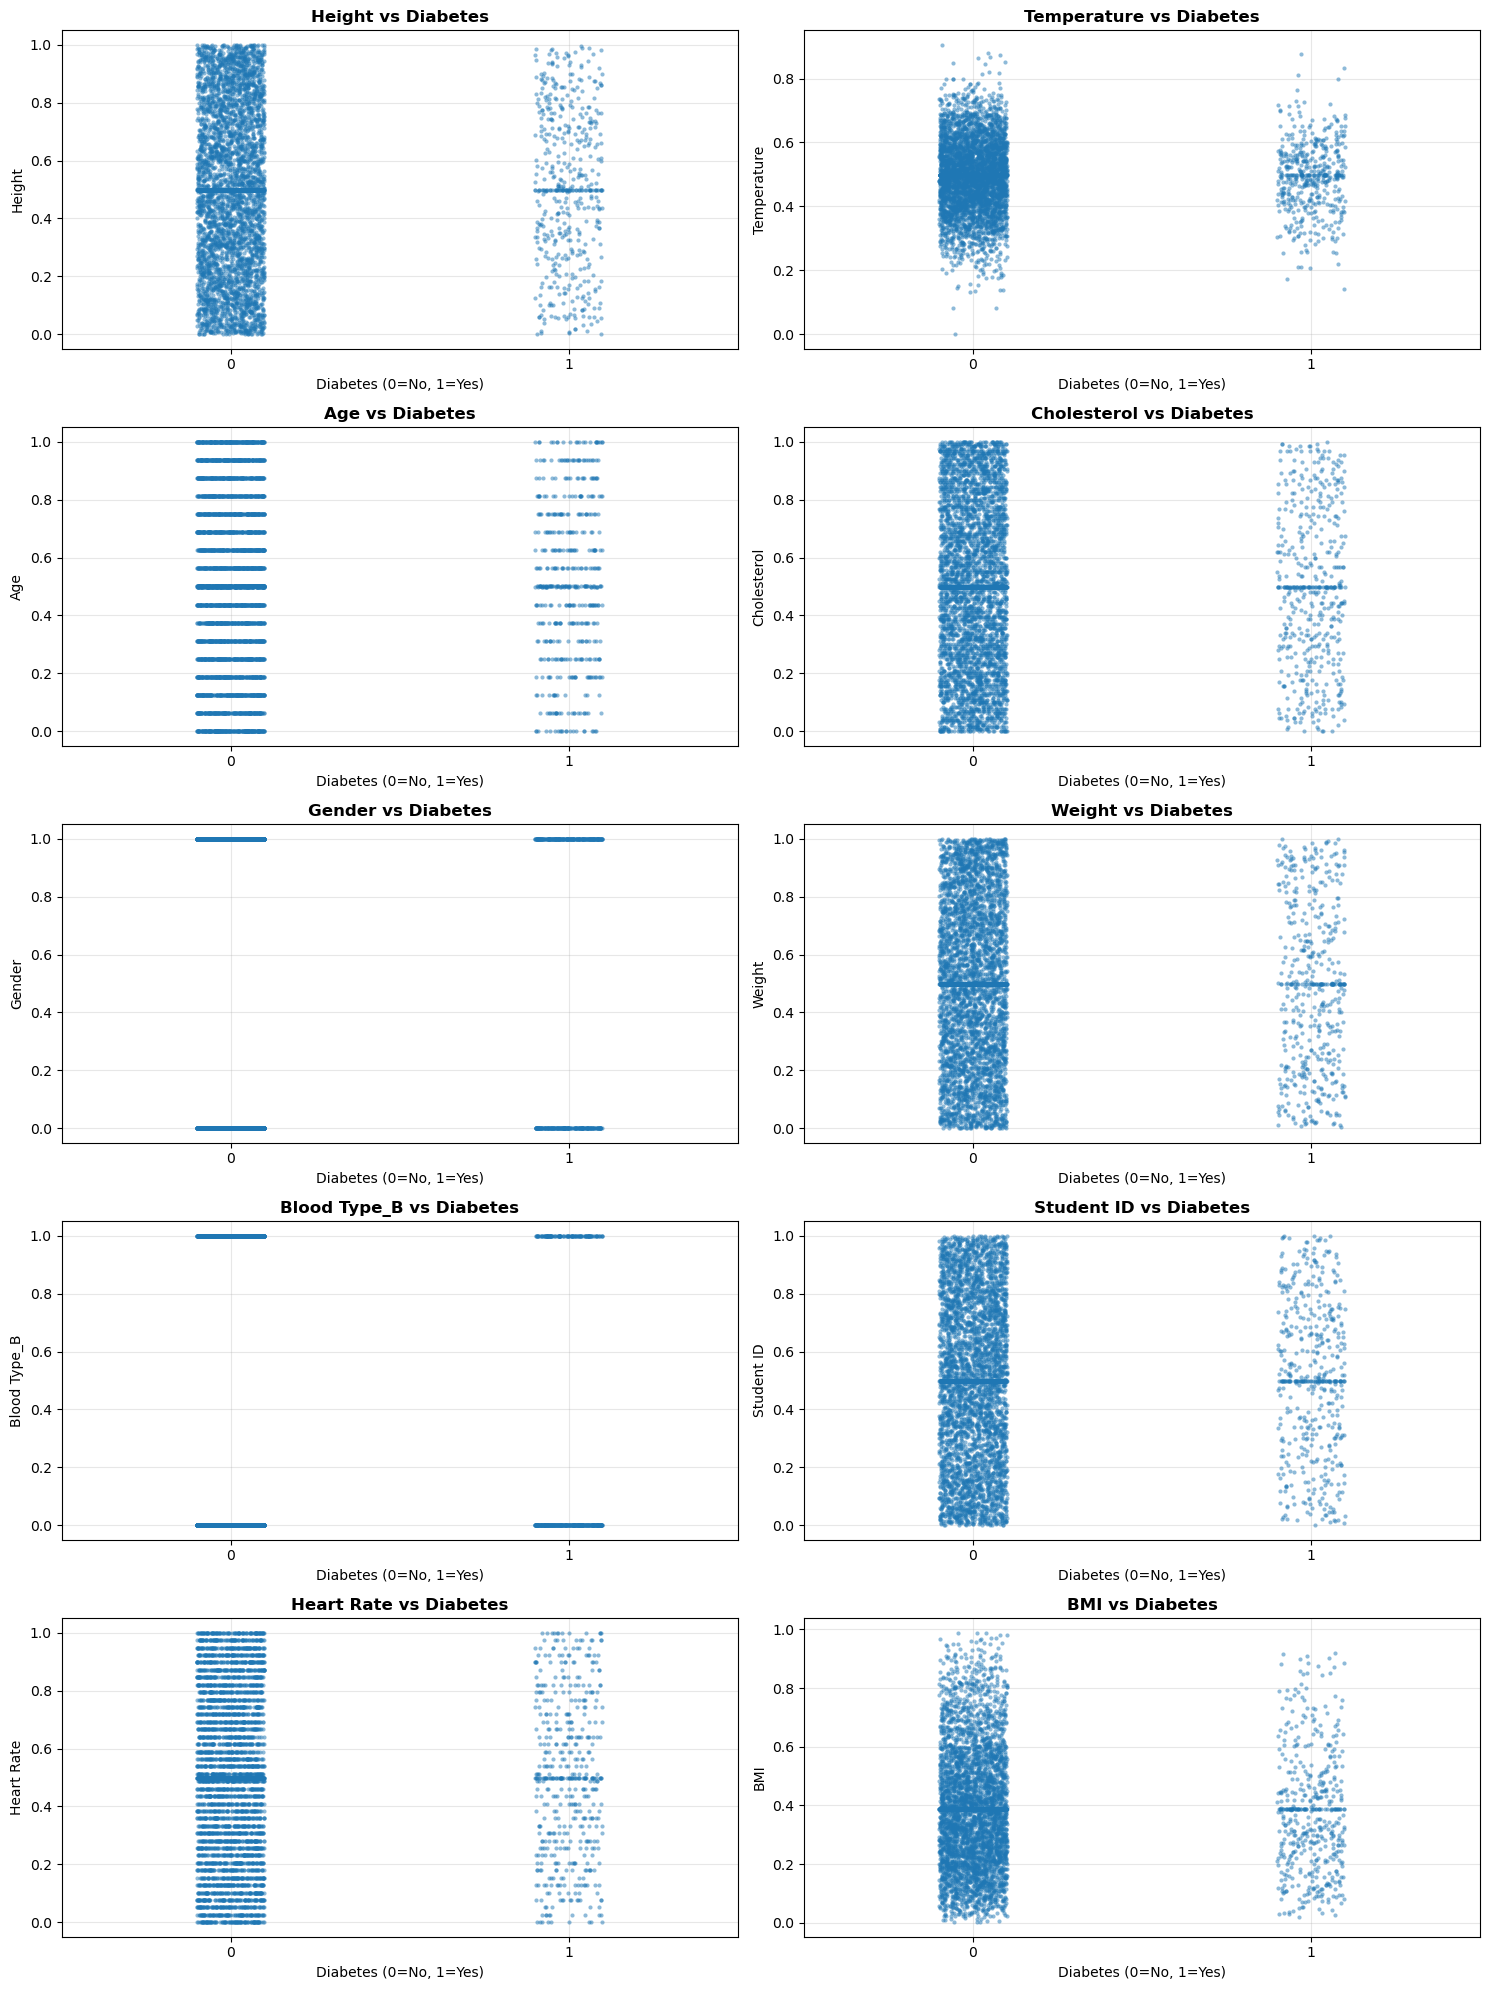

In [19]:
sample_size = min(5000, len(data_for_corr))
data_sample = data_for_corr.sample(n=sample_size, random_state=42)
# 1D scatter plots for top 10 features
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

for i, feature in enumerate(top_10_features):
    sns.stripplot(x='Diabetes', y=feature, data=data_sample, ax=axes[i], 
                  jitter=True, alpha=0.5, size=3)
    axes[i].set_title(f'{feature} vs Diabetes', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Diabetes (0=No, 1=Yes)')
    axes[i].set_ylabel(feature)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Select top 10 features for modeling
X_final = X_scaled[top_10_features].copy()

# Ensure all data is numeric (convert bool to float)
X_final = X_final.astype(float)

print(f"\n{'='*80}")
print(f"Final dataset shape with top 10 features: {X_final.shape}")
print(f"Target shape: {y_numeric.shape}")
print(f"Any NaN in features? {X_final.isnull().sum().sum()}")
print(f"Any NaN in target? {y_numeric.isnull().sum()}")

print("\n" + "="*80)
print("TRAIN/VALIDATION/TEST SPLIT (70:15:15)")
print("="*80)

# Stratified split: 70% train, 15% validation, 15% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_final, y_numeric, test_size=0.15, stratify=y_numeric, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, stratify=y_train_val, random_state=42
)  # 0.176 * 0.85 ≈ 0.15

print(f"\nTrain set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

total = len(X_final)
print(f"\nActual split ratios:")
print(f"  Train: {len(X_train)/total:.3f} ({len(X_train):,} samples)")
print(f"  Val:   {len(X_val)/total:.3f} ({len(X_val):,} samples)")
print(f"  Test:  {len(X_test)/total:.3f} ({len(X_test):,} samples)")

print(f"\nClass distribution in splits:")
print(f"  Train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"  Val:   {y_val.value_counts(normalize=True).to_dict()}")
print(f"  Test:  {y_test.value_counts(normalize=True).to_dict()}")


Final dataset shape with top 10 features: (169625, 10)
Target shape: (169625,)
Any NaN in features? 0
Any NaN in target? 0

TRAIN/VALIDATION/TEST SPLIT (70:15:15)

Train set: (118805, 10), (118805,)
Validation set: (25376, 10), (25376,)
Test set: (25444, 10), (25444,)

Actual split ratios:
  Train: 0.700 (118,805 samples)
  Val:   0.150 (25,376 samples)
  Test:  0.150 (25,444 samples)

Class distribution in splits:
  Train: {0: 0.8998695341105173, 1: 0.10013046588948277}
  Val:   {0: 0.8998660151324086, 1: 0.10013398486759142}
  Test:  {0: 0.8998585128124509, 1: 0.10014148718754913}


In [21]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
batch_size = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created:")
print(f"  Train loader: {len(train_loader)} batches")
print(f"  Val loader: {len(val_loader)} batches")
print(f"  Test loader: {len(test_loader)} batches")

DataLoaders created:
  Train loader: 465 batches
  Val loader: 100 batches
  Test loader: 100 batches


In [22]:
print("\n" + "="*80)
print("NEURAL NETWORK ARCHITECTURES")
print("="*80)

# Define different architectures
class FNN_Architecture1(nn.Module):
    """Architecture 1: [10 -> 64 -> 32 -> 1]"""
    def __init__(self, input_size):
        super(FNN_Architecture1, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x

class FNN_Architecture2(nn.Module):
    """Architecture 2: [10 -> 128 -> 64 -> 32 -> 1]"""
    def __init__(self, input_size):
        super(FNN_Architecture2, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc4(x))
        return x

class FNN_Architecture3(nn.Module):
    """Architecture 3: [10 -> 32 -> 16 -> 8 -> 1]"""
    def __init__(self, input_size):
        super(FNN_Architecture3, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 8)
        self.fc4 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

class FNN_Architecture4(nn.Module):
    """Architecture 4: [10 -> 64 -> 64 -> 32 -> 1] with BatchNorm"""
    def __init__(self, input_size):
        super(FNN_Architecture4, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.25)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))
        return x

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=10):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    # Load best model
    model.load_state_dict(best_model_state)
    return train_losses, val_losses, best_val_loss

# Evaluation function
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        y_pred_prob = model(X_test).squeeze().numpy()
        y_pred = (y_pred_prob > 0.5).astype(int)
        y_true = y_test.squeeze().numpy()
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auroc = roc_auc_score(y_true, y_pred_prob)
    
    return accuracy, precision, f1, auroc, y_pred_prob




NEURAL NETWORK ARCHITECTURES



TRAINING ALL ARCHITECTURES WITH SMOTE + CLASS WEIGHTS
Original training set: (118805, 10), (118805,)
After SMOTE: (213818, 10), (213818,)
Class distribution after SMOTE: {0: 106909, 1: 106909}
Positive class weight after SMOTE: 1.00

Training: Architecture 1: [10->64->32->1]
  Epoch [10/50], Train Loss: 0.6932, Val Loss: 0.6933
  Epoch [20/50], Train Loss: 0.6931, Val Loss: 0.6958
  Early stopping at epoch 24

Test Set Performance:
  Accuracy:  0.8999
  Precision: 0.0000
  F1-Score:  0.0000
  AUROC:     0.4948

Training: Architecture 2: [10->128->64->32->1]
  Epoch [10/50], Train Loss: 0.6932, Val Loss: 0.6932
  Epoch [20/50], Train Loss: 0.6932, Val Loss: 0.6932
  Early stopping at epoch 22

Test Set Performance:
  Accuracy:  0.8999
  Precision: 0.0000
  F1-Score:  0.0000
  AUROC:     0.4967

Training: Architecture 3: [10->32->16->8->1]
  Epoch [10/50], Train Loss: 0.6932, Val Loss: 0.6933
  Early stopping at epoch 17

Test Set Performance:
  Accuracy:  0.8999
  Precision: 0.0000
  F

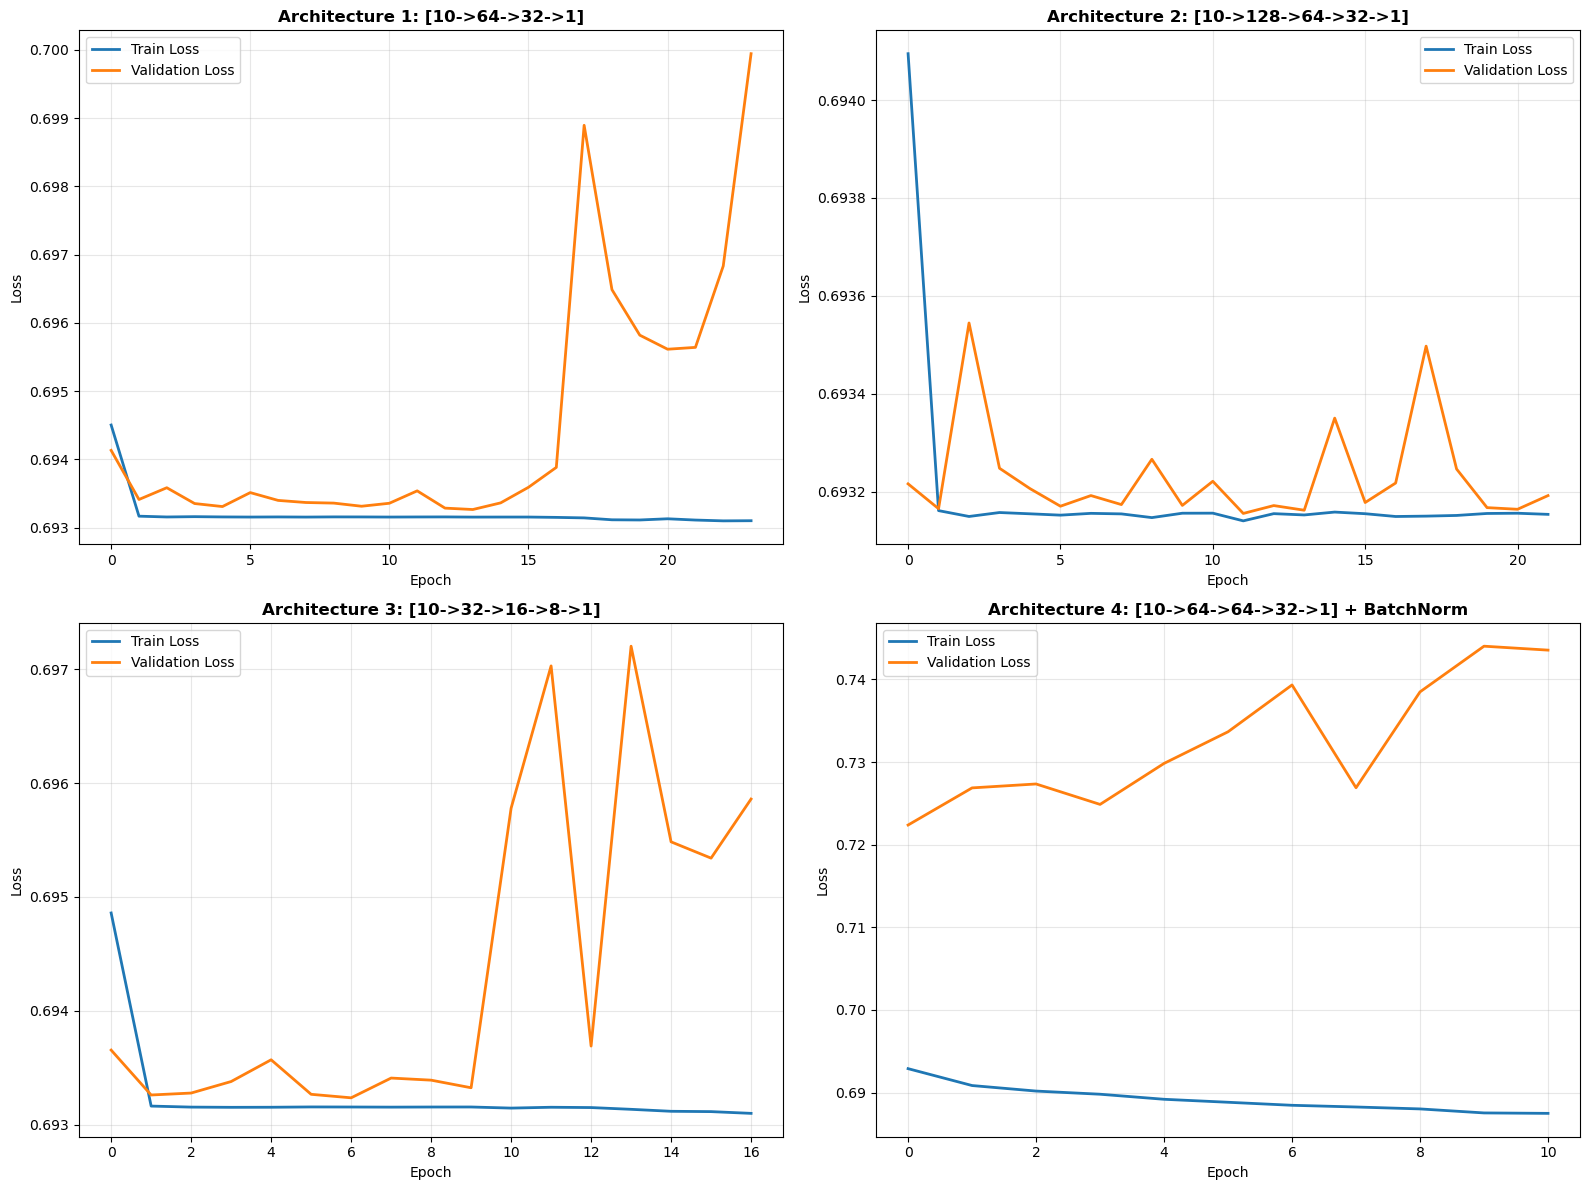

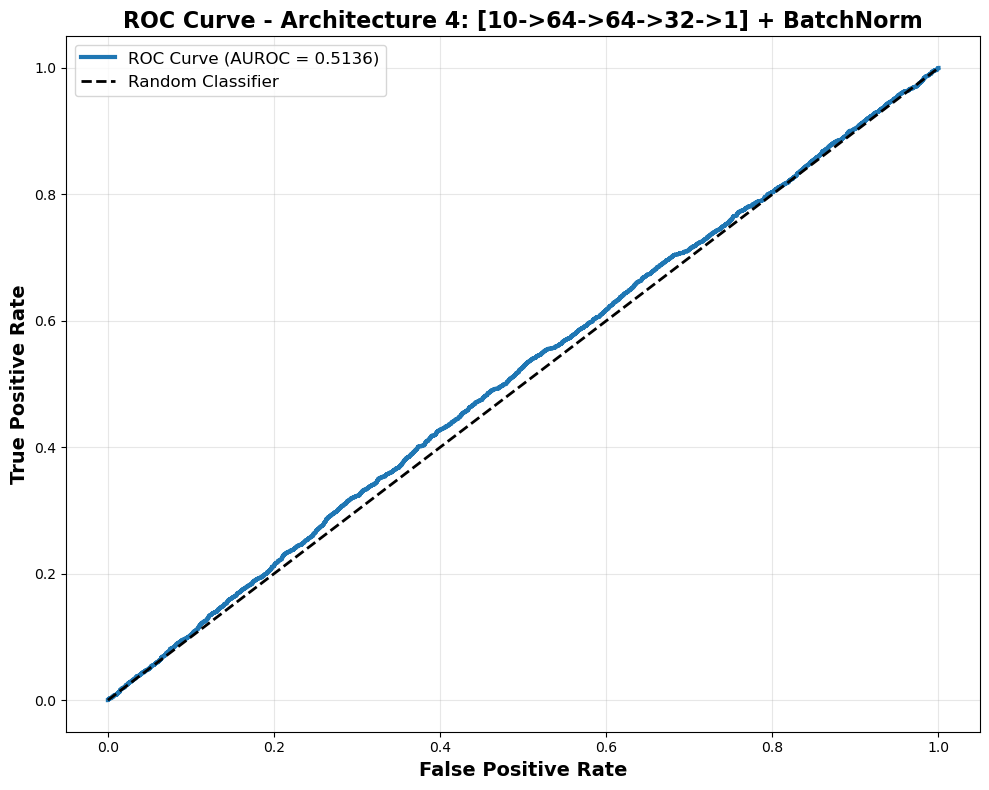

In [23]:
print("\n" + "="*80)
print("TRAINING ALL ARCHITECTURES WITH SMOTE + CLASS WEIGHTS")
print("="*80)

from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set: {X_train.shape}, {y_train.shape}")
print(f"After SMOTE: {X_train_smote.shape}, {y_train_smote.shape}")
print(f"Class distribution after SMOTE: {y_train_smote.value_counts().to_dict()}")

# Convert to tensors
X_train_tensor = torch.tensor(X_train_smote.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote.values, dtype=torch.float32).unsqueeze(1)

# Recreate train loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Calculate class weights (now balanced, but keep for safety)
num_neg = (y_train_smote == 0).sum()
num_pos = (y_train_smote == 1).sum()
pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float32) if num_pos > 0 else torch.tensor(1.0)

print(f"Positive class weight after SMOTE: {pos_weight:.2f}")

input_size = X_train.shape[1]
architectures = [
    ("Architecture 1: [10->64->32->1]", FNN_Architecture1(input_size)),
    ("Architecture 2: [10->128->64->32->1]", FNN_Architecture2(input_size)),
    ("Architecture 3: [10->32->16->8->1]", FNN_Architecture3(input_size)),
    ("Architecture 4: [10->64->64->32->1] + BatchNorm", FNN_Architecture4(input_size))
]

results = []

for arch_name, model in architectures:
    print(f"\n{'='*80}")
    print(f"Training: {arch_name}")
    print(f"{'='*80}")
    
    # Use BCEWithLogitsLoss with class weights
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    
    train_losses, val_losses, best_val_loss = train_model(
        model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=10
    )
    
    # Evaluate on test set
    acc, prec, f1, auroc, y_pred_prob = evaluate_model(model, X_test_tensor, y_test_tensor)
    
    results.append({
        'name': arch_name,
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'accuracy': acc,
        'precision': prec,
        'f1_score': f1,
        'auroc': auroc,
        'y_pred_prob': y_pred_prob
    })
    
    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUROC:     {auroc:.4f}")

print("\n" + "="*80)
print("SUMMARY OF ALL MODELS WITH SMOTE + CLASS WEIGHTS")
print("="*80)

summary_df = pd.DataFrame([{
    'Architecture': r['name'],
    'Val Loss': f"{r['best_val_loss']:.4f}",
    'Accuracy': f"{r['accuracy']:.4f}",
    'Precision': f"{r['precision']:.4f}",
    'F1-Score': f"{r['f1_score']:.4f}",
    'AUROC': f"{r['auroc']:.4f}"
} for r in results])

print("\n", summary_df.to_string(index=False))

# Find best model based on F1-score
best_model_idx = np.argmax([r['f1_score'] for r in results])
best_result = results[best_model_idx]

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_result['name']}")
print(f"{'='*80}")
print(f"Validation Loss: {best_result['best_val_loss']:.4f}")
print(f"Test Accuracy:   {best_result['accuracy']:.4f}")
print(f"Test Precision:  {best_result['precision']:.4f}")
print(f"Test F1-Score:   {best_result['f1_score']:.4f}")
print(f"Test AUROC:      {best_result['auroc']:.4f}")

# Plot training curves for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, result in enumerate(results):
    axes[i].plot(result['train_losses'], label='Train Loss', linewidth=2)
    axes[i].plot(result['val_losses'], label='Validation Loss', linewidth=2)
    axes[i].set_title(result['name'], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ROC Curve for best model
fpr, tpr, thresholds = roc_curve(y_test_tensor.squeeze().numpy(), best_result['y_pred_prob'])

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=3, label=f"ROC Curve (AUROC = {best_result['auroc']:.4f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title(f'ROC Curve - {best_result["name"]}', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()